TEST - Mask number 441

In [11]:
import sys
import os

# Add the project root folder path to sys.path
# project_path = '/home/santiago/Doctorado/Entrenamientos/renato/pucpr_pibic_semantic_segmentation'
project_path = '/media/renato/Data/Work/pucpr_pibic_semantic_segmentation/'
sys.path.append(os.path.abspath(project_path))

from dotenv import load_dotenv
from core.validation import get_valid_image_number
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

### Setup ###
# Load variables from .env file
load_dotenv()

# Base Path for image folder
# base_mask_folder: str = r"C:\Users\SLR02\Pictures\prueba 3\FinalImagePPM_Mask"
# output_folder: str = os.getenv("OUTPUT_FOLDER")
# mask_path: str = os.path.join(base_mask_folder, f"{441}.png")

base_mask_folder: str = os.getenv("BASE_MASK_V2_FOLDER")
img_number: str = get_valid_image_number()
mask_path: str = os.path.join(base_mask_folder, f"{img_number}.png")

# Load and Convert Images
bgr_img = cv.imread(mask_path, 1)
hsv_img = cv.cvtColor(bgr_img, cv.COLOR_BGR2HSV)


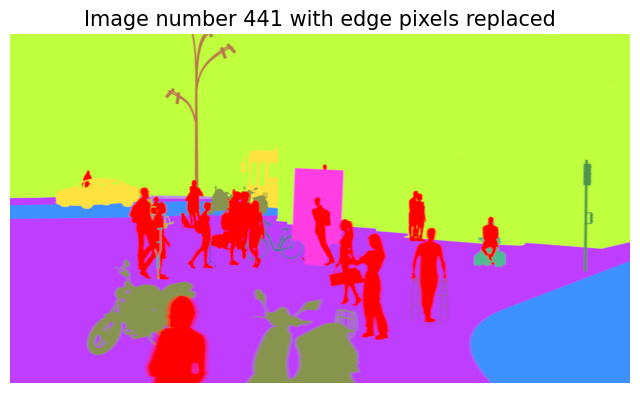

In [12]:
plt.figure(figsize=[8, 8])
plt.imshow(cv.cvtColor(bgr_img, cv.COLOR_BGR2RGB))
# plt.title("Imagen con píxeles del borde reemplazados", fontdict={'fontsize': 25})
plt.title(f"Image number {img_number} with edge pixels replaced", fontdict={'fontsize': 15})
plt.axis('off')
plt.show()

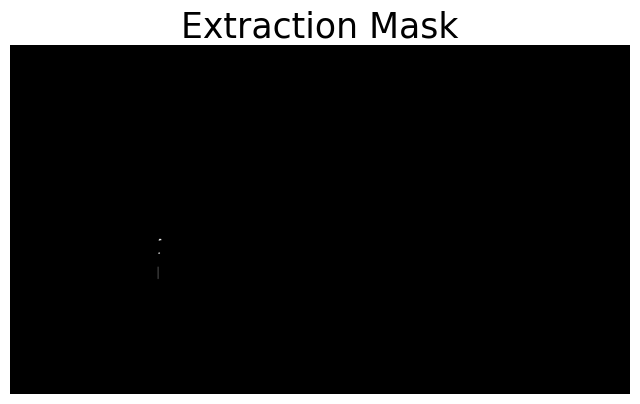

In [13]:
### Process 1 - Extraction of the desired color ###
# Define limits for the color you want to extract in HSV
lower_bound = np.array([92, 132, 183])
upper_bound = np.array([98, 151, 188])
mask_extraction = cv.inRange(hsv_img, lower_bound, upper_bound)

# Display the extraction mask
plt.figure(figsize=[8, 8])
plt.imshow(mask_extraction, cmap='gray')
plt.title("Extraction Mask", fontdict={'fontsize': 25})
plt.axis('off')
plt.show()

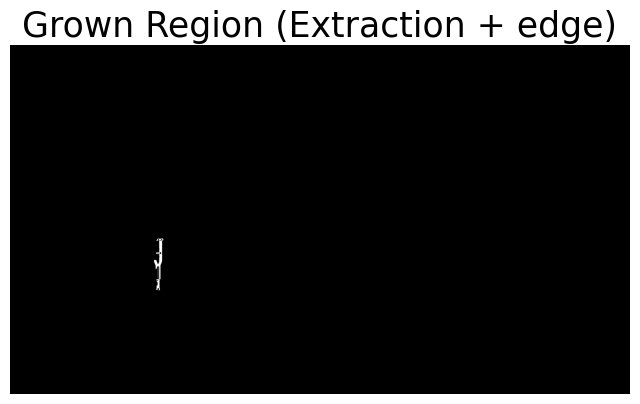

In [14]:
import collections

### Define target color ###
# Average extraction range: ((92+98)//2, (132+151)//2, (183+188)//2) = [95, 141, 185]
target_color = np.array([(92 + 98) // 2, (132 + 151) // 2, (183 + 188) // 2])

### Region growing from extraction ###
# A region growing mask is created. Initially, it contains the extraction.
region_mask = np.zeros_like(mask_extraction, dtype=np.uint8)
region_mask[mask_extraction == 255] = 255

# We use a queue to implement region growth
queue = collections.deque()

# We add the initial pixels of the extraction
indexes = np.column_stack(np.where(mask_extraction == 255))
for index in indexes:
    queue.append(tuple(index))

# Helper function: boundary condition based on the obtained ranges in HSV
def fulfill_condition(H, S, V):
    # For the Hue component, it is considered to be on the edge if it is >=151 or <=18 (circular logic)
    return ((H >= 151 or H <= 18) and (72 <= S <= 193) and (166 <= V <= 251))

# We perform the growth: for each pixel in the region, its neighbors are analyzed.
while queue:
    i, j = queue.popleft()
    # For 8 Neighbors (it's possible expand the neighborhood if necessary)
    for di, dj in [
                    (-1, -1), (-1, 0), (-1, 1),
                    (0, -1),           (0, 1),
                    (1, -1),  (1, 0),  (1, 1)
                ]:
        ni, nj = i + di, j + dj
        # Check that the neighbor is within the image
        if 0 <= ni < hsv_img.shape[0] and 0 <= nj < hsv_img.shape[1]:
            # If the neighbor is not yet part of the growth region:
            if region_mask[ni, nj] == 0:
                H, S, V = hsv_img[ni, nj]
                if fulfill_condition(H, S, V):
                    region_mask[ni, nj] = 255
                    queue.append((ni, nj))

# Display the grown region
plt.figure(figsize=[8, 8])
plt.imshow(region_mask, cmap='gray')
plt.title("Grown Region (Extraction + edge)", fontdict={'fontsize': 25})
plt.axis('off')
plt.show()
